In [ ]:
# =============================================================================
# HÜCRE 1: Google Drive Bağlantısı ve Kütüphane Kurulumu
# =============================================================================
# Bu hücre Colab ortamını hazırlar: Drive mount, gerekli kütüphaneler ve
# proje genelinde kullanılacak sabit path değişkenlerini tanımlar.

from google.colab import drive
drive.mount('/content/drive')

# Gerekli kütüphanelerin kurulumu
!pip install -q -U torchao peft transformers datasets evaluate sacrebleu accelerate nltk

import os, json, warnings
import numpy as np
import torch

warnings.filterwarnings("ignore")

# ── Sabit Path Değişkenleri ──────────────────────────────────────────────────
BASE_DIR    = "/content/drive/MyDrive/NLLB_Egitim_Verisi"
TRAIN_PATH  = f"{BASE_DIR}/train.jsonl"
VALID_PATH  = f"{BASE_DIR}/valid.jsonl"
TEST_PATH   = f"{BASE_DIR}/test.jsonl"
FLORES_PATH = f"{BASE_DIR}/flores_test.jsonl"
SAVE_DIR    = f"{BASE_DIR}/FineTuned_Model"
CKPT_DIR    = f"{BASE_DIR}/checkpoints"
MODEL_NAME  = "facebook/nllb-200-distilled-600M"

# Dosya varlık kontrolü
for path in [TRAIN_PATH, VALID_PATH, TEST_PATH, FLORES_PATH]:
    assert os.path.exists(path), f"HATA: {path} bulunamadı!"
print("✓ Tüm veri dosyaları bulundu.")
print(f"✓ GPU: {torch.cuda.get_device_name(0)} — {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB VRAM")


# =============================================================================
# HÜCRE 2: Tokenizer Yükleme ve Dil Kodu Haritası
# =============================================================================
# NLLB tokenizer yüklenir, kaynak dil sabitlenir (tur_Latn) ve
# dil kodu → NLLB ID eşleme tablosu oluşturulur.

from transformers import AutoTokenizer

# ── Dil Kodu Haritası ────────────────────────────────────────────────────────
LANG_CODE_MAP = {"tr-az": "azj_Latn", "tr-tk": "tuk_Latn"}

# ── Tokenizer Yükleme ───────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.src_lang = "tur_Latn"  # ← KESİN KURAL: Kaynak dil her zaman Türkçe

# Dil token ID'lerini önceden hesapla
# NOT: lang_code_to_id sözlüğü transformers >= 4.38'de kaldırıldı.
# convert_tokens_to_ids() her versiyonda çalışan evrensel yöntemdir.
LANG_IDS = {k: tokenizer.convert_tokens_to_ids(v) for k, v in LANG_CODE_MAP.items()}

print(f"✓ Tokenizer yüklendi — Vocab boyutu: {tokenizer.vocab_size}")
print(f"  TR-AZ (azj_Latn) token ID: {LANG_IDS['tr-az']}")
print(f"  TR-TK (tuk_Latn) token ID: {LANG_IDS['tr-tk']}")


# =============================================================================
# HÜCRE 3: preprocess_function ve DataCollator
# =============================================================================
# Dinamik hedef dil ataması yapan tokenizasyon fonksiyonu.
# DİKKAT: as_target_tokenizer() KULLANILMIYOR — deprecated.
# Bunun yerine tokenizer(src, text_target=tgt, ...) güncel yöntemi kullanılır.
# KRİTİK: tokenizer.tgt_lang her dil grubu için AYRI ayarlanmalıdır,
# aksi halde labels dizisine yanlış dil token'ı prepend edilir.

from transformers import DataCollatorForSeq2Seq

def preprocess_function(examples, target_lang_code, max_len=128):
    """
    Hedef dil parametrik olarak alınır ve tokenizer'a zorunlu olarak bildirilir.
    Bu sayede labels (etiketler) doğru dil prefix'i ile oluşturulur.

    - Kaynak metin (src) Türkçe olarak tokenize edilir.
    - Hedef metin (tgt) text_target parametresiyle tokenize edilir.
    - max_length = 128 kesin kuraldır.
    - padding=False → DataCollatorForSeq2Seq dinamik padding yapacak.
    """
    sources = [ex["src"] for ex in examples["translation"]]
    targets = [ex["tgt"] for ex in examples["translation"]]

    # Kaynak ve hedef dili her çağrıda garanti et
    tokenizer.src_lang = "tur_Latn"
    tokenizer.tgt_lang = target_lang_code  # ← KRİTİK: Hedef dil token'ını labels'a doğru yazmak için ZORUNLU

    # Güncel tokenizasyon yöntemi (as_target_tokenizer yerine text_target)
    model_inputs = tokenizer(
        sources,
        text_target=targets,
        max_length=max_len,
        truncation=True,
        padding=False  # DataCollator halledecek
    )

    return model_inputs


# DataCollator — gereksiz padding'i önler, label'ları -100 ile padler
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=None,  # Model sonra atanacak
    label_pad_token_id=-100,    # compute_metrics'te -100 → pad_token_id dönüşümü yapılacak
    pad_to_multiple_of=8,       # FP16 tensor hizalama optimizasyonu
    padding=True
)

print("✓ preprocess_function ve DataCollator tanımlandı.")


# =============================================================================
# HÜCRE 4: Veri Seti Yükleme ve Dil Bazlı Bölümleme
# =============================================================================
# JSONL dosyaları yüklenir, HER DİL GRUBU AYRI AYRI tokenize edilir.
# Train seti de dillere bölünür → ayrı tokenize → concatenate + shuffle.
# Bu, labels'a doğru dil token'ının yazılması için ZORUNLUDUR.

from datasets import load_dataset, concatenate_datasets

# ── Ham Veri Yükleme ─────────────────────────────────────────────────────────
raw_train = load_dataset("json", data_files=TRAIN_PATH, split="train")
raw_valid = load_dataset("json", data_files=VALID_PATH, split="train")
raw_test  = load_dataset("json", data_files=TEST_PATH,  split="train")

print(f"✓ Ham veriler yüklendi — Train: {len(raw_train)}, Valid: {len(raw_valid)}, Test: {len(raw_test)}")

# ── Dil Bazlı Bölümleme (tokenizasyon ÖNCESİ) ──────────────────────────────
# Train seti DAHİL tüm setler dillere göre bölünür
train_az = raw_train.filter(lambda x: x["lang"] == "tr-az")
train_tk = raw_train.filter(lambda x: x["lang"] == "tr-tk")

valid_az = raw_valid.filter(lambda x: x["lang"] == "tr-az")
valid_tk = raw_valid.filter(lambda x: x["lang"] == "tr-tk")

test_az  = raw_test.filter(lambda x: x["lang"] == "tr-az")
test_tk  = raw_test.filter(lambda x: x["lang"] == "tr-tk")

print(f"  Train — TR-AZ: {len(train_az)}, TR-TK: {len(train_tk)}")
print(f"  Valid — TR-AZ: {len(valid_az)}, TR-TK: {len(valid_tk)}")
print(f"  Test  — TR-AZ: {len(test_az)}, TR-TK: {len(test_tk)}")

# ── Hedef Dile Göre Ayrı Ayrı Tokenizasyon ──────────────────────────────────
# Her dil grubu kendi hedef dil koduyla tokenize edilir
# Bu sayede labels dizisinin başına DOĞRU dil token'ı prepend edilir
cols = raw_train.column_names  # ["translation", "lang"]

train_az_ds = train_az.map(lambda x: preprocess_function(x, "azj_Latn"), batched=True, remove_columns=cols)
train_tk_ds = train_tk.map(lambda x: preprocess_function(x, "tuk_Latn"), batched=True, remove_columns=cols)

valid_az_ds = valid_az.map(lambda x: preprocess_function(x, "azj_Latn"), batched=True, remove_columns=cols)
valid_tk_ds = valid_tk.map(lambda x: preprocess_function(x, "tuk_Latn"), batched=True, remove_columns=cols)

test_az_ds  = test_az.map(lambda x: preprocess_function(x, "azj_Latn"), batched=True, remove_columns=cols)
test_tk_ds  = test_tk.map(lambda x: preprocess_function(x, "tuk_Latn"), batched=True, remove_columns=cols)

# ── Train Setini Tekrar Birleştir ve Karıştır (Shuffle) ─────────────────────
# Modelin dilleri sırayla değil, karışık öğrenmesi için ZORUNLU
train_ds = concatenate_datasets([train_az_ds, train_tk_ds]).shuffle(seed=42)

print(f"\n✓ Tokenizasyon tamamlandı.")
print(f"  Train (AZ+TK karışık): {len(train_ds)} örnek")
print(f"  Valid AZ: {len(valid_az_ds)}, Valid TK: {len(valid_tk_ds)}")
print(f"  Test AZ: {len(test_az_ds)}, Test TK: {len(test_tk_ds)}")



# =============================================================================
# HÜCRE 5: Base Model Yükleme (FP16)
# =============================================================================
# NLLB-200 distilled 600M modeli FP16 formatında GPU'ya yüklenir.
# device_map="auto" ile GPU'ya otomatik yerleştirilir (~2.4GB VRAM).

from transformers import AutoModelForSeq2SeqLM

model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

print(f"✓ Base model yüklendi — {MODEL_NAME}")
print(f"  Toplam parametre: {sum(p.numel() for p in model.parameters()):,}")
print(f"  VRAM kullanımı: {torch.cuda.memory_allocated() / 1e9:.2f} GB")



# =============================================================================
# HÜCRE 5.1: compute_metrics Fonksiyonu (BLEU + chrF + METEOR)
# =============================================================================
# Üç metriği birden hesaplayan sade fonksiyon.
# Hücre 5.5'ten ÖNCE tanımlanmalıdır — base model değerlendirmesinde kullanılır.
# Dil prefix'i bu fonksiyonda EKLENMİYOR — CustomTrainer'ın metric_key_prefix
# mekanizması bunu otomatik halleder (örn: eval_tr-az_bleu).
# SDD'nin FR-05 gereksinimi METEOR'u zorunlu kılar.

import evaluate
import nltk
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)

bleu_metric   = evaluate.load("sacrebleu")
chrf_metric   = evaluate.load("chrf")
meteor_metric = evaluate.load("meteor")

def compute_metrics(eval_preds):
    """
    BLEU, chrF ve METEOR hesaplayan temiz fonksiyon.
    Dil prefix'i CustomTrainer tarafından metric_key_prefix ile eklenir.
    """

    # predict_with_generate=True olduğunda preds tuple dönebilir
    if isinstance(preds, tuple):
        preds = preds[0]

    # -100 (ignore_index) değerlerini pad_token_id ile değiştir
    # OverflowError hatasını önlemek için hem labels hem de preds için yapılmalıdır.
    preds = np.where(preds != -100, preds, tokenizer.pad_token_id)
    preds, labels = eval_preds
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    decoded_preds  = tokenizer.batch_decode(preds, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds  = [pred.strip() for pred in decoded_preds]
    decoded_labels = [label.strip() for label in decoded_labels]

    bleu_result   = bleu_metric.compute(predictions=decoded_preds, references=[[ref] for ref in decoded_labels])
    chrf_result   = chrf_metric.compute(predictions=decoded_preds, references=decoded_labels)
    meteor_result = meteor_metric.compute(predictions=decoded_preds, references=decoded_labels)

    return {
        "bleu":   round(bleu_result["score"], 4),
        "chrf":   round(chrf_result["score"], 4),
        "meteor": round(meteor_result["meteor"], 4),
    }

print("✓ compute_metrics fonksiyonu tanımlandı (BLEU + chrF + METEOR).")


# =============================================================================
# HÜCRE 5.5: SAF (BASE) MODELİN DEĞERLENDİRİLMESİ
# =============================================================================
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments

print("="*60)
print("  SAF (EĞİTİLMEMİŞ) MODEL PERFORMANSI ÖLÇÜLÜYOR...")
print("="*60)

base_eval_args = Seq2SeqTrainingArguments(
    output_dir="./base_eval",
    per_device_eval_batch_size=16,
    predict_with_generate=True,
    generation_max_length=256,
    fp16=True,
    report_to="none"
)

base_trainer = Seq2SeqTrainer(
    model=model,
    args=base_eval_args,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer
)

def evaluate_base_model(dataset, lang_key, dataset_name):
    model.generation_config.forced_bos_token_id = LANG_IDS[lang_key]
    preds = base_trainer.predict(dataset)
    b, c, m = preds.metrics["test_bleu"], preds.metrics["test_chrf"], preds.metrics["test_meteor"]
    print(f"  [SAF - {dataset_name}] {lang_key.upper()}: BLEU={b:.2f} | chrF={c:.2f} | METEOR={m:.4f}")

# ── 1. Saf Model İç Test Skoru ──
print("\n─── Saf Model İç Test Skoru ───")
evaluate_base_model(test_az_ds, "tr-az", "Test")
evaluate_base_model(test_tk_ds, "tr-tk", "Test")

# ── 2. Saf Model FLORES Skoru (Veri burada yükleniyor) ──
print("\n─── Saf Model FLORES Skoru ───")
raw_flores = load_dataset("json", data_files=FLORES_PATH, split="train")
flores_az  = raw_flores.filter(lambda x: x["lang"] == "tr-az")
flores_tk  = raw_flores.filter(lambda x: x["lang"] == "tr-tk")

print(f"  FLORES yüklendi — TR-AZ: {len(flores_az)}, TR-TK: {len(flores_tk)}")

flores_az_ds = flores_az.map(lambda x: preprocess_function(x, "azj_Latn", max_len=256), batched=True, remove_columns=raw_flores.column_names)
flores_tk_ds = flores_tk.map(lambda x: preprocess_function(x, "tuk_Latn", max_len=256), batched=True, remove_columns=raw_flores.column_names)

evaluate_base_model(flores_az_ds, "tr-az", "FLORES")
evaluate_base_model(flores_tk_ds, "tr-tk", "FLORES")

# Base model testleri bitti — modeli LoRA öncesi tarafsız duruma geri getir
model.generation_config.forced_bos_token_id = None



# =============================================================================
# HÜCRE 6: LoRA (PEFT) Konfigürasyonu ve Model Hazırlama
# =============================================================================
# KRİTİK SIRA: 1) base model yükle → 2) enable_input_require_grads() → 3) get_peft_model()
# enable_input_require_grads() UNUTULMAMALI — gradient_checkpointing ile LoRA
# birlikte çalışabilmesi için ZORUNLUDUR.

from peft import LoraConfig, get_peft_model, TaskType

# ── LoRA Konfigürasyonu (6.txt KESİN DEĞERLERİ) ─────────────────────────────
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "out_proj", "fc1", "fc2"],
    task_type=TaskType.SEQ_2_SEQ_LM
)

# ── KRİTİK: enable_input_require_grads → get_peft_model SIRASI ──────────────
model.enable_input_require_grads()  # ← get_peft_model'den ÖNCE çağrılmalı!
model = get_peft_model(model, lora_config)

# DataCollator'a model referansı ver
data_collator.model = model

# Eğitilebilir parametre sayısını doğrula
model.print_trainable_parameters()
print(f"  VRAM kullanımı (LoRA sonrası): {torch.cuda.memory_allocated() / 1e9:.2f} GB")




# =============================================================================
# HÜCRE 8: CustomTrainer Sınıfı Tanımı (DÜZELTİLMİŞ)
# =============================================================================
from transformers import Seq2SeqTrainer

class CustomTrainer(Seq2SeqTrainer):
    def evaluate(self, eval_dataset=None, ignore_keys=None, metric_key_prefix="eval", **kwargs):
        """
        Trainer sözlük(dict) eval_dataset'i otomatik olarak parçalar ve bu fonksiyonu
        her dataset için ayrı çağırır. Hangi dilde olduğunu 'metric_key_prefix'
        parametresinden (örn: 'eval_tr-az') anlıyoruz.
        """
        # Hangi dilin değerlendirildiğini prefix'ten tespit et
        if "tr-az" in metric_key_prefix:
            self.model.generation_config.forced_bos_token_id = LANG_IDS["tr-az"]
        elif "tr-tk" in metric_key_prefix:
            self.model.generation_config.forced_bos_token_id = LANG_IDS["tr-tk"]
        else:
            self.model.generation_config.forced_bos_token_id = None

        # Orijinal değerlendirme döngüsünü çağır
        return super().evaluate(eval_dataset, ignore_keys, metric_key_prefix, **kwargs)

print("✓ CustomTrainer sınıfı tanımlandı (Bypass ve Early Stopping hatası giderildi).")


# =============================================================================
# HÜCRE 9: Seq2SeqTrainingArguments (T4 GPU için optimize)
# =============================================================================
# Tüm eğitim hiperparametreleri 6.txt'deki KESİN değerlerle tanımlanır.
# VRAM kısıtlarına göre hesaplanmış parametreler — DEĞİŞTİRİLMEMELİ.

from transformers import Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(
    output_dir=CKPT_DIR,

    # ── Batch & Gradient ─────────────────────────────────────────────────
    per_device_train_batch_size=16,     # T4 için; OOM alınırsa 8'e düşür
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=4,      # Efektif batch = 16 × 4 = 64
    gradient_checkpointing=True,        # HAYATİ — 15GB VRAM'de OOM önlemi

    # ── Learning Rate & Scheduler ────────────────────────────────────────
    learning_rate=3e-4,                 # LoRA için optimize edilmiş yüksek LR
    lr_scheduler_type="cosine",         # Smooth warmup + decay
    warmup_steps=187,                    # = int(3748 * 0.05) — warmup_ratio v5.2'de kaldırılacak
    num_train_epochs=4,                 # EarlyStopping ile korunur

    # ── Precision ────────────────────────────────────────────────────────
    fp16=True,                          # FP16 eğitim — hız + VRAM tasarrufu

    # ── Kaydetme & Loglama ───────────────────────────────────────────────
    save_total_limit=2,                 # Drive alanı tasarrufu — son 2 checkpoint
    logging_steps=50,                   # Her 50 adımda log bas
    logging_first_step=True,

    # ── Değerlendirme Stratejisi ─────────────────────────────────────────
    eval_strategy="epoch",        # Her epoch sonunda değerlendir
    save_strategy="epoch",              # Her epoch sonunda kaydet

    # ── Generasyon Ayarları ──────────────────────────────────────────────
    predict_with_generate=True,         # Gerçek çeviri üretimi ile skorlama
    generation_max_length=128,          # Tokenizasyonla tutarlı

    # ── En İyi Model Seçimi ──────────────────────────────────────────────
    load_best_model_at_end=True,
    metric_for_best_model="eval_tr-az_bleu",  # AZ BLEU'ya göre en iyi model
    greater_is_better=True,             # BLEU yüksek = iyi

    # ── Diğer ────────────────────────────────────────────────────────────
    report_to="none",                   # W&B veya TensorBoard kullanmıyoruz
    dataloader_num_workers=2,
    remove_unused_columns=False,        # Özel sütunlar varsa hata önler
)

print("✓ Eğitim argümanları tanımlandı.")
print(f"  Efektif batch boyutu: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"  Toplam epoch: {training_args.num_train_epochs}")
print(f"  En iyi model metriği: {training_args.metric_for_best_model}")


# =============================================================================
# HÜCRE 10: Trainer Başlatma ve Eğitimi Çalıştırma
# =============================================================================
# CustomTrainer örneği oluşturulur, eval_dataset dict olarak verilir,
# compute_metrics doğrudan atanır ve eğitim başlatılır.

from transformers import EarlyStoppingCallback

# ── Trainer Oluştur ──────────────────────────────────────────────────────────
trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset={"tr-az": valid_az_ds, "tr-tk": valid_tk_ds},  # Dict formatı
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,  # Doğrudan atama — factory pattern'a gerek yok
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
)

print("✓ CustomTrainer başlatıldı.")
print(f"  Train örnekleri: {len(train_ds)}")
print(f"  Eval setleri: TR-AZ ({len(valid_az_ds)}), TR-TK ({len(valid_tk_ds)})")
print(f"  EarlyStoppingCallback: patience=1")

# ── EĞİTİMİ BAŞLAT ──────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  EĞİTİM BAŞLIYOR...")
print("="*60 + "\n")

train_result = trainer.train()

# Eğitim sonuçlarını yazdır
print("\n" + "="*60)
print("  EĞİTİM TAMAMLANDI")
print("="*60)
metrics = train_result.metrics
print(f"  Toplam eğitim süresi: {metrics.get('train_runtime', 0):.0f} saniye")
print(f"  Eğitim loss: {metrics.get('train_loss', 0):.4f}")
print(f"  Toplam adım: {metrics.get('train_steps', 0)}")


# =============================================================================
# HÜCRE 11: Test Seti + FLORES Final Değerlendirmesi
# =============================================================================

print("="*60)
print("  FİNAL DEĞERLENDİRME (EĞİTİLMİŞ MODEL)")
print("="*60 + "\n")

def evaluate_single(model_to_eval, dataset, lang_key, dataset_name):
    model_to_eval.generation_config.forced_bos_token_id = LANG_IDS[lang_key]
    predictions = trainer.predict(dataset)
    bleu   = predictions.metrics["test_bleu"]
    chrf   = predictions.metrics["test_chrf"]
    meteor = predictions.metrics["test_meteor"]
    print(f"  [{dataset_name}] {lang_key.upper()}: BLEU={bleu:.2f} | chrF={chrf:.2f} | METEOR={meteor:.4f}")
    return {"bleu": bleu, "chrf": chrf, "meteor": meteor}


# ── 1) İç Test Seti Değerlendirmesi (128 Token Limiti ile) ──────────────────
print("─── İç Test Seti (test.jsonl) ───")
test_results = {}
test_results["tr-az"] = evaluate_single(model, test_az_ds, "tr-az", "Test")
test_results["tr-tk"] = evaluate_single(model, test_tk_ds, "tr-tk", "Test")

# ── 2) FLORES Benchmark Değerlendirmesi (256 Token Limiti ile) ──────────────
print("\n─── FLORES Benchmark (flores_test.jsonl) ───")

# KRİTİK EKLENTİ: Eğitilmiş modelin üretim sınırını FLORES için 256'ya çıkar
trainer.args.generation_max_length = 256

flores_results = {}
flores_results["tr-az"] = evaluate_single(model, flores_az_ds, "tr-az", "FLORES")
flores_results["tr-tk"] = evaluate_single(model, flores_tk_ds, "tr-tk", "FLORES")

# ── Karşılaştırmalı Sonuç Tablosu ───────────────────────────────────────────
print("\n" + "="*70)
print("  KARŞILAŞTIRMALI SONUÇLAR")
print("="*70)
print(f"{'Dil':<10} {'Veri Seti':<15} {'BLEU':>8} {'chrF':>8} {'METEOR':>8}")
print("-"*55)
for lang in ["tr-az", "tr-tk"]:
    for ds_name, results in [("İç Test", test_results), ("FLORES", flores_results)]:
        r = results[lang]
        print(f"{lang.upper():<10} {ds_name:<15} {r['bleu']:>8.2f} {r['chrf']:>8.2f} {r['meteor']:>8.4f}")
    print()

# SDD NFR-01 Başarı Kriteri Kontrolü
print("─── Başarı Kriterleri (SDD NFR-01) ───")
az_bleu = flores_results["tr-az"]["bleu"]
tk_bleu = flores_results["tr-tk"]["bleu"]
print(f"  TR-AZ FLORES BLEU: {az_bleu:.2f} {'✓ BAŞARILI (≥25)' if az_bleu >= 25 else '⚠ Hedef: ≥25'}")
print(f"  TR-TK FLORES BLEU: {tk_bleu:.2f} {'✓ BAŞARILI (≥18)' if tk_bleu >= 18 else '⚠ Hedef: ≥18'}")


# =============================================================================
# HÜCRE 12: LoRA Merge + Drive'a Kaydetme
# =============================================================================
# LoRA ağırlıkları base model ile birleştirilir (merge_and_unload).
# Birleştirilmiş nihai model ve tokenizer Drive'a kaydedilir.
# Merge sonrası PEFT bağımlılığı kalmaz — tam bağımsız model.

print("\n" + "="*60)
print("  MODEL BİRLEŞTİRME VE KAYDETME")
print("="*60 + "\n")

# ── LoRA Merge ───────────────────────────────────────────────────────────────
print("→ LoRA ağırlıkları base model ile birleştiriliyor...")

# KRİTİK: Modelin kalıcı olarak tek bir dile kilitlenmesini engelle.
# Değerlendirme döngüsünden kalan son forced_bos_token_id (Türkmence) temizlenir.
# Aksi halde generation_config.json'a bu ID kazınır ve model hep TK üretir.
model.generation_config.forced_bos_token_id = None

merged_model = model.merge_and_unload()
print("✓ merge_and_unload() tamamlandı — PEFT bağımlılığı kaldırıldı.")

# ── Drive'a Kaydet ───────────────────────────────────────────────────────────
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"→ Model kaydediliyor → {SAVE_DIR}")
merged_model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

# Kayıt doğrulaması
saved_files = os.listdir(SAVE_DIR)
print(f"\n✓ Model başarıyla kaydedildi!")
print(f"  Konum: {SAVE_DIR}")
print(f"  Dosyalar ({len(saved_files)}):")
for f in sorted(saved_files):
    size_mb = os.path.getsize(os.path.join(SAVE_DIR, f)) / 1e6
    print(f"    📄 {f} ({size_mb:.1f} MB)")

print("\n" + "="*60)
print("  ✅ TÜM İŞLEMLER TAMAMLANDI")
print("  Model artık Hugging Face'e yüklenmeye veya")
print(f"  doğrudan {SAVE_DIR} üzerinden kullanıma hazırdır.")
print("="*60)

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 81.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 124.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 19.4 MB/s eta 0:00:00
✓ Tüm veri dosyaları bulundu.
✓ GPU: Tesla T4 — 15.6 GB VRAM


config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

...

✓ Base model yüklendi — facebook/nllb-200-distilled-600M
  Toplam parametre: 615,073,792
  VRAM kullanımı: 1.23 GB


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


✓ compute_metrics fonksiyonu tanımlandı (BLEU + chrF + METEOR).
  SAF (EĞİTİLMEMİŞ) MODEL PERFORMANSI ÖLÇÜLÜYOR...

─── Saf Model İç Test Skoru ───


  [SAF - Test] TR-AZ: BLEU=14.40 | chrF=44.74 | METEOR=0.4206


OverflowError: out of range integral type conversion attempted

In [ ]:
def compute_metrics(eval_preds):
    """
    BLEU, chrF ve METEOR hesaplayan temiz fonksiyon.
    Dil prefix'i CustomTrainer tarafından metric_key_prefix ile eklenir.
    """
    # UnboundLocalError hatasını önlemek için doğrudan özellikleri alıyoruz
    preds = eval_preds.predictions
    labels = eval_preds.label_ids

    # predict_with_generate=True olduğunda preds tuple dönebilir
    if isinstance(preds, tuple):
        preds = preds[0]

    # -100 (ignore_index) değerlerini pad_token_id ile değiştir
    # OverflowError hatasını önlemek için hem labels hem de preds için yapılmalıdır.
    preds = np.where(preds != -100, preds, tokenizer.pad_token_id)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    decoded_preds  = tokenizer.batch_decode(preds, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds  = [pred.strip() for pred in decoded_preds]
    decoded_labels = [label.strip() for label in decoded_labels]

    bleu_result   = bleu_metric.compute(predictions=decoded_preds, references=[[ref] for ref in decoded_labels])
    chrf_result   = chrf_metric.compute(predictions=decoded_preds, references=decoded_labels)
    meteor_result = meteor_metric.compute(predictions=decoded_preds, references=decoded_labels)

    return {
        "bleu":   round(bleu_result["score"], 4),
        "chrf":   round(chrf_result["score"], 4),
        "meteor": round(meteor_result["meteor"], 4),
    }

# =============================================================================
# HÜCRE 5.5: SAF (BASE) MODELİN DEĞERLENDİRİLMESİ
# =============================================================================
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments

print("="*60)
print("  SAF (EĞİTİLMEMİŞ) MODEL PERFORMANSI ÖLÇÜLÜYOR...")
print("="*60)

base_eval_args = Seq2SeqTrainingArguments(
    output_dir="./base_eval",
    per_device_eval_batch_size=16,
    predict_with_generate=True,
    generation_max_length=256,
    fp16=True,
    report_to="none"
)

base_trainer = Seq2SeqTrainer(
    model=model,
    args=base_eval_args,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer
)

def evaluate_base_model(dataset, lang_key, dataset_name):
    model.generation_config.forced_bos_token_id = LANG_IDS[lang_key]
    preds = base_trainer.predict(dataset)
    b, c, m = preds.metrics["test_bleu"], preds.metrics["test_chrf"], preds.metrics["test_meteor"]
    print(f"  [SAF - {dataset_name}] {lang_key.upper()}: BLEU={b:.2f} | chrF={c:.2f} | METEOR={m:.4f}")

# ── 1. Saf Model İç Test Skoru ──
print("\n─── Saf Model İç Test Skoru ───")
evaluate_base_model(test_az_ds, "tr-az", "Test")
evaluate_base_model(test_tk_ds, "tr-tk", "Test")

# ── 2. Saf Model FLORES Skoru (Veri burada yükleniyor) ──
print("\n─── Saf Model FLORES Skoru ───")
raw_flores = load_dataset("json", data_files=FLORES_PATH, split="train")
flores_az  = raw_flores.filter(lambda x: x["lang"] == "tr-az")
flores_tk  = raw_flores.filter(lambda x: x["lang"] == "tr-tk")

print(f"  FLORES yüklendi — TR-AZ: {len(flores_az)}, TR-TK: {len(flores_tk)}")

flores_az_ds = flores_az.map(lambda x: preprocess_function(x, "azj_Latn", max_len=256), batched=True, remove_columns=raw_flores.column_names)
flores_tk_ds = flores_tk.map(lambda x: preprocess_function(x, "tuk_Latn", max_len=256), batched=True, remove_columns=raw_flores.column_names)

evaluate_base_model(flores_az_ds, "tr-az", "FLORES")
evaluate_base_model(flores_tk_ds, "tr-tk", "FLORES")

# Base model testleri bitti — modeli LoRA öncesi tarafsız duruma geri getir
model.generation_config.forced_bos_token_id = None



# =============================================================================
# HÜCRE 6: LoRA (PEFT) Konfigürasyonu ve Model Hazırlama
# =============================================================================
# KRİTİK SIRA: 1) base model yükle → 2) enable_input_require_grads() → 3) get_peft_model()
# enable_input_require_grads() UNUTULMAMALI — gradient_checkpointing ile LoRA
# birlikte çalışabilmesi için ZORUNLUDUR.

from peft import LoraConfig, get_peft_model, TaskType

# ── LoRA Konfigürasyonu (6.txt KESİN DEĞERLERİ) ─────────────────────────────
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "out_proj", "fc1", "fc2"],
    task_type=TaskType.SEQ_2_SEQ_LM
)

# ── KRİTİK: enable_input_require_grads → get_peft_model SIRASI ──────────────
model.enable_input_require_grads()  # ← get_peft_model'den ÖNCE çağrılmalı!
model = get_peft_model(model, lora_config)

# DataCollator'a model referansı ver
data_collator.model = model

# Eğitilebilir parametre sayısını doğrula
model.print_trainable_parameters()
print(f"  VRAM kullanımı (LoRA sonrası): {torch.cuda.memory_allocated() / 1e9:.2f} GB")




# =============================================================================
# HÜCRE 8: CustomTrainer Sınıfı Tanımı (DÜZELTİLMİŞ)
# =============================================================================
from transformers import Seq2SeqTrainer

class CustomTrainer(Seq2SeqTrainer):
    def evaluate(self, eval_dataset=None, ignore_keys=None, metric_key_prefix="eval", **kwargs):
        """
        Trainer sözlük(dict) eval_dataset'i otomatik olarak parçalar ve bu fonksiyonu
        her dataset için ayrı çağırır. Hangi dilde olduğunu 'metric_key_prefix'
        parametresinden (örn: 'eval_tr-az') anlıyoruz.
        """
        # Hangi dilin değerlendirildiğini prefix'ten tespit et
        if "tr-az" in metric_key_prefix:
            self.model.generation_config.forced_bos_token_id = LANG_IDS["tr-az"]
        elif "tr-tk" in metric_key_prefix:
            self.model.generation_config.forced_bos_token_id = LANG_IDS["tr-tk"]
        else:
            self.model.generation_config.forced_bos_token_id = None

        # Orijinal değerlendirme döngüsünü çağır
        return super().evaluate(eval_dataset, ignore_keys, metric_key_prefix, **kwargs)

print("✓ CustomTrainer sınıfı tanımlandı (Bypass ve Early Stopping hatası giderildi).")


# =============================================================================
# HÜCRE 9: Seq2SeqTrainingArguments (T4 GPU için optimize)
# =============================================================================
# Tüm eğitim hiperparametreleri 6.txt'deki KESİN değerlerle tanımlanır.
# VRAM kısıtlarına göre hesaplanmış parametreler — DEĞİŞTİRİLMEMELİ.

from transformers import Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(
    output_dir=CKPT_DIR,

    # ── Batch & Gradient ─────────────────────────────────────────────────
    per_device_train_batch_size=16,     # T4 için; OOM alınırsa 8'e düşür
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=4,      # Efektif batch = 16 × 4 = 64
    gradient_checkpointing=True,        # HAYATİ — 15GB VRAM'de OOM önlemi

    # ── Learning Rate & Scheduler ────────────────────────────────────────
    learning_rate=3e-4,                 # LoRA için optimize edilmiş yüksek LR
    lr_scheduler_type="cosine",         # Smooth warmup + decay
    warmup_steps=187,                    # = int(3748 * 0.05) — warmup_ratio v5.2'de kaldırılacak
    num_train_epochs=4,                 # EarlyStopping ile korunur

    # ── Precision ────────────────────────────────────────────────────────
    fp16=True,                          # FP16 eğitim — hız + VRAM tasarrufu

    # ── Kaydetme & Loglama ───────────────────────────────────────────────
    save_total_limit=2,                 # Drive alanı tasarrufu — son 2 checkpoint
    logging_steps=50,                   # Her 50 adımda log bas
    logging_first_step=True,

    # ── Değerlendirme Stratejisi ─────────────────────────────────────────
    eval_strategy="epoch",        # Her epoch sonunda değerlendir
    save_strategy="epoch",              # Her epoch sonunda kaydet

    # ── Generasyon Ayarları ──────────────────────────────────────────────
    predict_with_generate=True,         # Gerçek çeviri üretimi ile skorlama
    generation_max_length=128,          # Tokenizasyonla tutarlı

    # ── En İyi Model Seçimi ──────────────────────────────────────────────
    load_best_model_at_end=True,
    metric_for_best_model="eval_tr-az_bleu",  # AZ BLEU'ya göre en iyi model
    greater_is_better=True,             # BLEU yüksek = iyi

    # ── Diğer ────────────────────────────────────────────────────────────
    report_to="none",                   # W&B veya TensorBoard kullanmıyoruz
    dataloader_num_workers=2,
    remove_unused_columns=False,        # Özel sütunlar varsa hata önler
)

print("✓ Eğitim argümanları tanımlandı.")
print(f"  Efektif batch boyutu: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"  Toplam epoch: {training_args.num_train_epochs}")
print(f"  En iyi model metriği: {training_args.metric_for_best_model}")


# =============================================================================
# HÜCRE 10: Trainer Başlatma ve Eğitimi Çalıştırma
# =============================================================================
# CustomTrainer örneği oluşturulur, eval_dataset dict olarak verilir,
# compute_metrics doğrudan atanır ve eğitim başlatılır.

from transformers import EarlyStoppingCallback

# ── Trainer Oluştur ──────────────────────────────────────────────────────────
trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset={"tr-az": valid_az_ds, "tr-tk": valid_tk_ds},  # Dict formatı
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,  # Doğrudan atama — factory pattern'a gerek yok
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
)

print("✓ CustomTrainer başlatıldı.")
print(f"  Train örnekleri: {len(train_ds)}")
print(f"  Eval setleri: TR-AZ ({len(valid_az_ds)}), TR-TK ({len(valid_tk_ds)})")
print(f"  EarlyStoppingCallback: patience=1")

# ── EĞİTİMİ BAŞLAT ──────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  EĞİTİM BAŞLIYOR...")
print("="*60 + "\n")

train_result = trainer.train()

# Eğitim sonuçlarını yazdır
print("\n" + "="*60)
print("  EĞİTİM TAMAMLANDI")
print("="*60)
metrics = train_result.metrics
print(f"  Toplam eğitim süresi: {metrics.get('train_runtime', 0):.0f} saniye")
print(f"  Eğitim loss: {metrics.get('train_loss', 0):.4f}")
print(f"  Toplam adım: {metrics.get('train_steps', 0)}")


# =============================================================================
# HÜCRE 11: Test Seti + FLORES Final Değerlendirmesi
# =============================================================================

print("="*60)
print("  FİNAL DEĞERLENDİRME (EĞİTİLMİŞ MODEL)")
print("="*60 + "\n")

def evaluate_single(model_to_eval, dataset, lang_key, dataset_name):
    model_to_eval.generation_config.forced_bos_token_id = LANG_IDS[lang_key]
    predictions = trainer.predict(dataset)
    bleu   = predictions.metrics["test_bleu"]
    chrf   = predictions.metrics["test_chrf"]
    meteor = predictions.metrics["test_meteor"]
    print(f"  [{dataset_name}] {lang_key.upper()}: BLEU={bleu:.2f} | chrF={chrf:.2f} | METEOR={meteor:.4f}")
    return {"bleu": bleu, "chrf": chrf, "meteor": meteor}


# ── 1) İç Test Seti Değerlendirmesi (128 Token Limiti ile) ──────────────────
print("─── İç Test Seti (test.jsonl) ───")
test_results = {}
test_results["tr-az"] = evaluate_single(model, test_az_ds, "tr-az", "Test")
test_results["tr-tk"] = evaluate_single(model, test_tk_ds, "tr-tk", "Test")

# ── 2) FLORES Benchmark Değerlendirmesi (256 Token Limiti ile) ──────────────
print("\n─── FLORES Benchmark (flores_test.jsonl) ───")

# KRİTİK EKLENTİ: Eğitilmiş modelin üretim sınırını FLORES için 256'ya çıkar
trainer.args.generation_max_length = 256

flores_results = {}
flores_results["tr-az"] = evaluate_single(model, flores_az_ds, "tr-az", "FLORES")
flores_results["tr-tk"] = evaluate_single(model, flores_tk_ds, "tr-tk", "FLORES")

# ── Karşılaştırmalı Sonuç Tablosu ───────────────────────────────────────────
print("\n" + "="*70)
print("  KARŞILAŞTIRMALI SONUÇLAR")
print("="*70)
print(f"{'Dil':<10} {'Veri Seti':<15} {'BLEU':>8} {'chrF':>8} {'METEOR':>8}")
print("-"*55)
for lang in ["tr-az", "tr-tk"]:
    for ds_name, results in [("İç Test", test_results), ("FLORES", flores_results)]:
        r = results[lang]
        print(f"{lang.upper():<10} {ds_name:<15} {r['bleu']:>8.2f} {r['chrf']:>8.2f} {r['meteor']:>8.4f}")
    print()

# SDD NFR-01 Başarı Kriteri Kontrolü
print("─── Başarı Kriterleri (SDD NFR-01) ───")
az_bleu = flores_results["tr-az"]["bleu"]
tk_bleu = flores_results["tr-tk"]["bleu"]
print(f"  TR-AZ FLORES BLEU: {az_bleu:.2f} {'✓ BAŞARILI (≥25)' if az_bleu >= 25 else '⚠ Hedef: ≥25'}")
print(f"  TR-TK FLORES BLEU: {tk_bleu:.2f} {'✓ BAŞARILI (≥18)' if tk_bleu >= 18 else '⚠ Hedef: ≥18'}")


# =============================================================================
# HÜCRE 12: LoRA Merge + Drive'a Kaydetme
# =============================================================================
# LoRA ağırlıkları base model ile birleştirilir (merge_and_unload).
# Birleştirilmiş nihai model ve tokenizer Drive'a kaydedilir.
# Merge sonrası PEFT bağımlılığı kalmaz — tam bağımsız model.

print("\n" + "="*60)
print("  MODEL BİRLEŞTİRME VE KAYDETME")
print("="*60 + "\n")

# ── LoRA Merge ───────────────────────────────────────────────────────────────
print("→ LoRA ağırlıkları base model ile birleştiriliyor...")

# KRİTİK: Modelin kalıcı olarak tek bir dile kilitlenmesini engelle.
# Değerlendirme döngüsünden kalan son forced_bos_token_id (Türkmence) temizlenir.
# Aksi halde generation_config.json'a bu ID kazınır ve model hep TK üretir.
model.generation_config.forced_bos_token_id = None

merged_model = model.merge_and_unload()
print("✓ merge_and_unload() tamamlandı — PEFT bağımlılığı kaldırıldı.")

# ── Drive'a Kaydet ───────────────────────────────────────────────────────────
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"→ Model kaydediliyor → {SAVE_DIR}")
merged_model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

# Kayıt doğrulaması
saved_files = os.listdir(SAVE_DIR)
print(f"\n✓ Model başarıyla kaydedildi!")
print(f"  Konum: {SAVE_DIR}")
print(f"  Dosyalar ({len(saved_files)}):")
for f in sorted(saved_files):
    size_mb = os.path.getsize(os.path.join(SAVE_DIR, f)) / 1e6
    print(f"    📄 {f} ({size_mb:.1f} MB)")

print("\n" + "="*60)
print("  ✅ TÜM İŞLEMLER TAMAMLANDI")
print("  Model artık Hugging Face'e yüklenmeye veya")
print(f"  doğrudan {SAVE_DIR} üzerinden kullanıma hazırdır.")
print("="*60)

  SAF (EĞİTİLMEMİŞ) MODEL PERFORMANSI ÖLÇÜLÜYOR...

─── Saf Model İç Test Skoru ───


  [SAF - Test] TR-AZ: BLEU=14.40 | chrF=44.74 | METEOR=0.4206


  [SAF - Test] TR-TK: BLEU=12.56 | chrF=39.57 | METEOR=0.3519

─── Saf Model FLORES Skoru ───


Generating train split: 0 examples [00:00, ? examples/s]

Filter:   0%|          | 0/4018 [00:00<?, ? examples/s]

...

  [Test] TR-TK: BLEU=39.56 | chrF=65.79 | METEOR=0.6248

─── FLORES Benchmark (flores_test.jsonl) ───


  [FLORES] TR-AZ: BLEU=10.80 | chrF=43.54 | METEOR=0.3224


  [FLORES] TR-TK: BLEU=11.34 | chrF=44.79 | METEOR=0.3313

  KARŞILAŞTIRMALI SONUÇLAR
Dil        Veri Seti           BLEU     chrF   METEOR
-------------------------------------------------------
TR-AZ      İç Test            25.19    54.04   0.5354
TR-AZ      FLORES             10.80    43.54   0.3224

TR-TK      İç Test            39.56    65.79   0.6248
TR-TK      FLORES             11.34    44.79   0.3313

─── Başarı Kriterleri (SDD NFR-01) ───
  TR-AZ FLORES BLEU: 10.80 ⚠ Hedef: ≥25
  TR-TK FLORES BLEU: 11.34 ⚠ Hedef: ≥18

  MODEL BİRLEŞTİRME VE KAYDETME

→ LoRA ağırlıkları base model ile birleştiriliyor...
✓ merge_and_unload() tamamlandı — PEFT bağımlılığı kaldırıldı.
→ Model kaydediliyor → /content/drive/MyDrive/NLLB_Egitim_Verisi/FineTuned_Model


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✓ Model başarıyla kaydedildi!
  Konum: /content/drive/MyDrive/NLLB_Egitim_Verisi/FineTuned_Model
  Dosyalar (5):
    📄 config.json (0.0 MB)
    📄 generation_config.json (0.0 MB)
    📄 model.safetensors (1230.2 MB)
    📄 tokenizer.json (32.2 MB)
    📄 tokenizer_config.json (0.0 MB)

  ✅ TÜM İŞLEMLER TAMAMLANDI
  Model artık Hugging Face'e yüklenmeye veya
  doğrudan /content/drive/MyDrive/NLLB_Egitim_Verisi/FineTuned_Model üzerinden kullanıma hazırdır.


In [ ]:
grafik oluşturma ve örnek çeviriler

In [2]:
# =============================================================================
# RAPOR İÇİN KARŞILAŞTIRMALI ÇEVİRİ ÖRNEKLERİ ÜRETME KODU (GÜNCELLENDİ)
# =============================================================================
import os
import torch
from google.colab import drive
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# 1. Google Drive'ı Bağla (Hatanın Çözümü)
drive.mount('/content/drive')

BASE_MODEL_NAME = "facebook/nllb-200-distilled-600M"
FINETUNED_MODEL_PATH = "/content/drive/MyDrive/NLLB_Egitim_Verisi/FineTuned_Model"

# Klasör kontrolü
if not os.path.exists(FINETUNED_MODEL_PATH):
    raise FileNotFoundError(f"HATA: {FINETUNED_MODEL_PATH} bulunamadı! Lütfen yolu kontrol edin.")

print("\n⏳ Tokenizer ve Modeller Yükleniyor (Bu işlem 1-2 dakika sürebilir)...")

# Tokenizer ve Modelleri Yükle (local_files_only=True ile internette aramasını yasaklıyoruz)
tokenizer = AutoTokenizer.from_pretrained(FINETUNED_MODEL_PATH, local_files_only=True)

# Taban (Saf) Modeli Yükle
base_model = AutoModelForSeq2SeqLM.from_pretrained(
    BASE_MODEL_NAME, torch_dtype=torch.float16, device_map="auto"
)

# Sizin Eğittiğiniz (Merged) Modeli Yükle
ft_model = AutoModelForSeq2SeqLM.from_pretrained(
    FINETUNED_MODEL_PATH, torch_dtype=torch.float16, device_map="auto", local_files_only=True
)

LANG_IDS = {"tr-az": "azj_Latn", "tr-tk": "tuk_Latn"}

def generate_translation(model, text, target_lang):
    """Tek bir cümle için hedef dile çeviri üretir."""
    tokenizer.src_lang = "tur_Latn"
    inputs = tokenizer(text, return_tensors="pt", max_length=128, truncation=True).to(model.device)

    forced_bos_token_id = tokenizer.convert_tokens_to_ids(LANG_IDS[target_lang])

    with torch.no_grad():
        generated_tokens = model.generate(
            **inputs,
            forced_bos_token_id=forced_bos_token_id,
            max_length=128,
            num_beams=4,
            repetition_penalty=1.5 # Tekrarlama hatasını önlemek için ceza parametresi
        )
    return tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)[0]

# 📝 TEST ETMEK İSTEDİĞİNİZ ÖRNEK CÜMLELER
sample_sentences = {
    "tr-az": [
        "Teşekkür ederim, görüşürüz.",
        "Hükümet, ekonomik kalkınma için yeni politikalar açıkladı.",
        "Bu projenin temel amacı doğrudan çeviri altyapısı kurmaktır."
    ],
    "tr-tk": [
        "Çocuklar bahçede oyun oynuyor.",
        "Lütfen bu soruyu açık bir şekilde yanıtlayın.",
        "Gelecek yıl yeni bir bilgisayar almayı planlıyorum."
    ]
}

# Sonuçları Rapor Formatında Yazdır
print("\n" + "="*80)
print("  MODEL ÇEVİRİ KARŞILAŞTIRMA RAPORU")
print("="*80)

for lang, sentences in sample_sentences.items():
    print(f"\n▶ DİL ÇİFTİ: {lang.upper()} (Hedef: {LANG_IDS[lang]})")
    print("-" * 70)
    for idx, src_text in enumerate(sentences, start=1):
        base_out = generate_translation(base_model, src_text, lang)
        ft_out   = generate_translation(ft_model, src_text, lang)

        print(f"Örnek {idx}:")
        print(f"  [KAYNAK TR]   : {src_text}")
        print(f"  [TABAN NLLB]  : {base_out}")
        print(f"  [İNCE-AYARLI] : {ft_out}")
        print("-" * 70)
print("\n✓ Çeviri örnekleri başarıyla üretildi.")

Mounted at /content/drive

⏳ Tokenizer ve Modeller Yükleniyor (Bu işlem 1-2 dakika sürebilir)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/509 [00:00<?, ?it/s]


  MODEL ÇEVİRİ KARŞILAŞTIRMA RAPORU

▶ DİL ÇİFTİ: TR-AZ (Hedef: azj_Latn)
----------------------------------------------------------------------
Örnek 1:
  [KAYNAK TR]   : Teşekkür ederim, görüşürüz.
  [TABAN NLLB]  : Təşəkkürlər, görüşəcəyik.
  [İNCE-AYARLI] : Təşəkkür edirəm, görüşəcəyik.
----------------------------------------------------------------------
Örnek 2:
  [KAYNAK TR]   : Hükümet, ekonomik kalkınma için yeni politikalar açıkladı.
  [TABAN NLLB]  : Hökumət iqtisadi inkişaf üçün yeni siyasətlər açıqlayıb.
  [İNCE-AYARLI] : Hökumət iqtisadi inkişaf üçün yeni siyasətlər açıqladı.
----------------------------------------------------------------------
Örnek 3:
  [KAYNAK TR]   : Bu projenin temel amacı doğrudan çeviri altyapısı kurmaktır.
  [TABAN NLLB]  : Bu layihənin əsas məqsədi birbaşa tərcümə infrastrukturunu qurmaqdır.
  [İNCE-AYARLI] : Bu layihənin əsas məqsədi birbaşa tərcümə infrastrukturunu qurmaqdır.
------------------------------------------------------------------

✓ Akademik Loss grafiği başarıyla üretildi ve 'nllb_lora_training_loss_curves.png' adıyla kaydedildi!


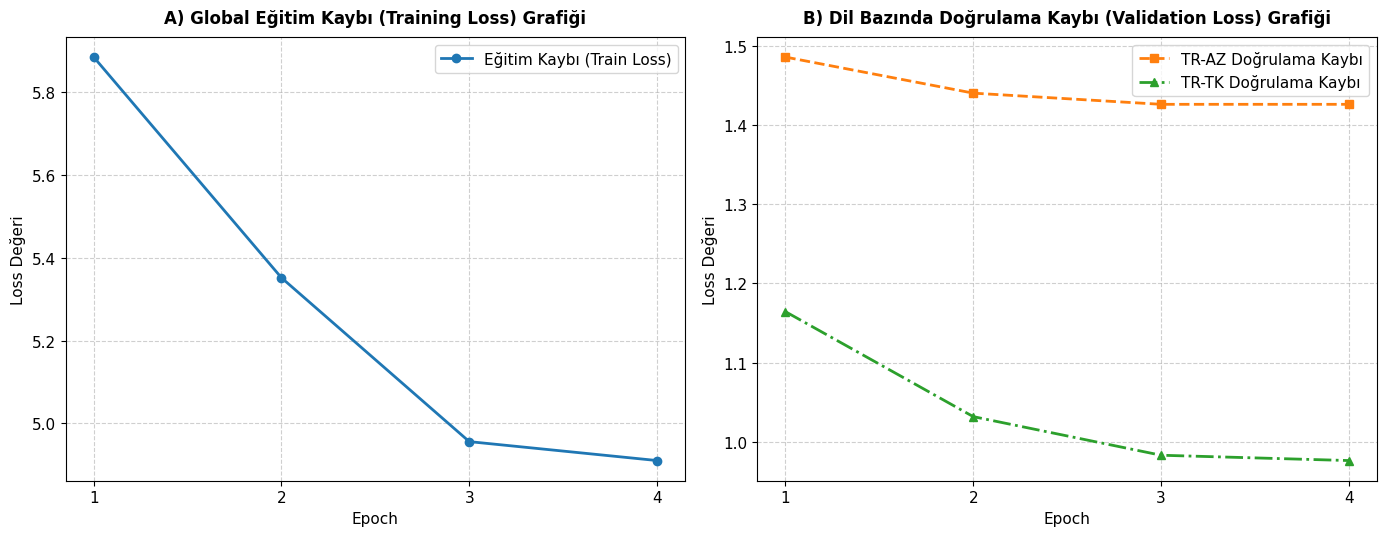

In [3]:
# =============================================================================
# RAPOR İÇİN MATPLOTLIB AKADEMİK LOSS GRAFİĞİ ÜRETME KODU
# =============================================================================
import matplotlib.pyplot as plt

# Çizelge 4.2'deki Kesin Eğitim Verileri
epochs = [1, 2, 3, 4]
training_loss = [5.8850, 5.3519, 4.9562, 4.9105]
valid_az_loss = [1.4855, 1.4400, 1.4259, 1.4259]
valid_tk_loss = [1.1644, 1.0320, 0.9833, 0.9766]

# Grafik Stil Ayarları (Akademik Format)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# ── 1. GRAFİK: EĞİTİM KAYBI (TRAINING LOSS) ──────────────────────────────────
ax1.plot(epochs, training_loss, color='#1f77b4', marker='o', linewidth=2, label='Eğitim Kaybı (Train Loss)')
ax1.set_title('A) Global Eğitim Kaybı (Training Loss) Grafiği', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Loss Değeri', fontsize=11)
ax1.set_xticks(epochs)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper right')

# ── 2. GRAFİK: DOĞRULAMA KAYBI (VALIDATION LOSS - AZ vs TK) ──────────────────
ax2.plot(epochs, valid_az_loss, color='#ff7f0e', marker='s', linewidth=2, linestyle='--', label='TR-AZ Doğrulama Kaybı')
ax2.plot(epochs, valid_tk_loss, color='#2ca02c', marker='^', linewidth=2, linestyle='-.', label='TR-TK Doğrulama Kaybı')
ax2.set_title('B) Dil Bazında Doğrulama Kaybı (Validation Loss) Grafiği', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Loss Değeri', fontsize=11)
ax2.set_xticks(epochs)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper right')

# Genel Düzenlemeler ve Kaydetme
plt.tight_layout()

# Grafiği bilgisayarınıza/Colab diskine yüksek kalitede kaydetmek için:
graph_path = "nllb_lora_training_loss_curves.png"
plt.savefig(graph_path, dpi=300, bbox_inches='tight')
print(f"✓ Akademik Loss grafiği başarıyla üretildi ve '{graph_path}' adıyla kaydedildi!")

# Ekranda Göster
plt.show()